Project Tasks
1. Data Loading and Exploration:
Utilize Pandas to load the dataset and explore its initial structure.
Summarize features, target variable, and their respective data types.
Conduct basic descriptive statistics for an overview of the dataset.


2. Data Cleaning and Preprocessing:
Address missing or null values.
Transform categorical data into numerical format using suitable methods.


3. Statistical Analysis with NumPy and SciPy:
Execute detailed statistical analysis on each feature, including:
Calculation of central tendency measures (mean, median, mode).
Analysis of variability (range, variance, standard deviation).
Evaluation of distribution shapes through skewness and kurtosis.
Perform hypothesis testing for statistical significance between groups (e.g., different price ranges).
Investigate feature-target correlations using SciPy.
Apply advanced SciPy statistical functions for deeper insights.


4. Data Visualization with Matplotlib:
Produce histograms, scatter plots, and box plots for data distribution and relationship insights.
Employ heatmaps for correlation visualization.
Ensure clarity in plots with appropriate titles, labels, and axis information.


5. Insight Synthesis and Conclusion:
Derive conclusions from statistical tests and visualizations.
Identify key determinants in mobile price classification.
Highlight any unexpected or significant findings.


# 1. Data Loading and Exploration

In [34]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

In [2]:
df = pd.read_csv("train.csv")
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_screen   2000

In [4]:
df.shape

(2000, 21)

In [5]:
df.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [6]:
df.nunique()

battery_power    1094
blue                2
clock_speed        26
dual_sim            2
fc                 20
four_g              2
int_memory         63
m_dep              10
mobile_wt         121
n_cores             8
pc                 21
px_height        1137
px_width         1109
ram              1562
sc_h               15
sc_w               19
talk_time          19
three_g             2
touch_screen        2
wifi                2
price_range         4
dtype: int64

In [7]:
df["price_range"].value_counts().sort_index()

price_range
0    500
1    500
2    500
3    500
Name: count, dtype: int64

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0


# 2. Data Cleaning and Preprocessing

In [9]:
(df["px_height"] == 0).sum()

np.int64(2)

In [10]:
(df["sc_w"] == 0).sum()

np.int64(180)

In [11]:
df.loc[
    df["sc_w"] == 0,
    ["sc_w", "sc_h", "px_height", "px_width", "price_range"]
].head(10)

,sc_w,sc_h,px_height,px_width,price_range
12,0,18,607,748,1
24,0,11,201,1245,1
33,0,7,178,1919,3
42,0,15,685,714,1
50,0,5,1042,1832,2
54,0,6,690,804,2
62,0,7,322,547,0
73,0,11,4,638,3
86,0,16,96,741,0
119,0,5,1445,1954,1


In [12]:
df.loc[df["sc_w"] > 0, "sc_w"].median()

np.float64(6.0)

In [13]:
df["sc_w"] = df["sc_w"].replace(0, np.nan)
df["sc_w"] = df["sc_w"].fillna(df["sc_w"].median())

In [14]:
(df["sc_w"] == 0).sum()

np.int64(0)

In [15]:
df["sc_w"] = df["sc_w"].astype(int)

In [16]:
df.loc[df["px_height"] > 0, "px_height"].median()

np.float64(565.5)

In [17]:
px_height_median = round(
    df.loc[df["px_height"] > 0, "px_height"].median()
)

px_height_median

566

In [18]:
df["px_height"] = df["px_height"].replace(0, px_height_median)

In [19]:
(df["px_height"] == 0).sum()

np.int64(0)


The dataset was initially very clean, with no missing values and no duplicated observations. The target variable `price_range` is also perfectly balanced, with 500 observations in each of the four classes.

Binary categorical features were already encoded numerically as 0 and 1, so no additional categorical encoding was required.
Binary categorical variables such as `blue`, `dual_sim`, `four_g`, `three_g`, `touch_screen`, and `wifi` were kept as 0/1 integer values because this representation is appropriate for numerical statistical analysis and correlation calculations.

During the plausibility checks, two numerical features contained invalid zero values. `sc_w` contained 180 zero values and `px_height` contained 2 zero values, although both variables represent physical screen dimensions that should be greater than zero.

The zero values in `sc_w` were therefore treated as missing values and replaced with the median of the valid observations (6). The two invalid `px_height` values were replaced with the rounded median of the valid observations (566).

After these corrections, the dataset was considered ready for statistical analysis.

# 3. Statistical Analysis

In [21]:
features = df.drop(columns="price_range")

In [22]:
from scipy import stats

statistical_summary = []

for column in features.columns:
    values = features[column].to_numpy()

    statistical_summary.append({
        "feature": column,
        "mean": np.mean(values),
        "median": np.median(values),
        "mode": stats.mode(values, keepdims=False).mode,
        "range": np.ptp(values),
        "variance": np.var(values, ddof=1),
        "std": np.std(values, ddof=1),
        "skewness": stats.skew(values, bias=False),
        "kurtosis": stats.kurtosis(values, bias=False)
    })

stats_df = pd.DataFrame(statistical_summary).set_index("feature").round(2)

stats_df

,mean,median,mode,range,variance,std,skewness,kurtosis
feature,,,,,,,,
battery_power,1238.52,1226.0,618.0,1497.0,193088.36,439.42,0.03,-1.22
blue,0.50,0.0,0.0,1.0,0.25,0.50,0.02,-2.00
clock_speed,1.52,1.5,0.5,2.5,0.67,0.82,0.18,-1.32
dual_sim,0.51,1.0,1.0,1.0,0.25,0.50,-0.04,-2.00
fc,4.31,3.0,0.0,19.0,18.85,4.34,1.02,0.28
four_g,0.52,1.0,1.0,1.0,0.25,0.50,-0.09,-1.99
int_memory,32.05,32.0,27.0,62.0,329.27,18.15,0.06,-1.22
m_dep,0.50,0.5,0.1,0.9,0.08,0.29,0.09,-1.27
mobile_wt,140.25,141.0,182.0,120.0,1253.14,35.40,0.01,-1.21


### Statistical Distribution Summary

The descriptive statistical analysis shows that most continuous features have relatively low skewness, indicating approximately symmetric distributions.

`fc` shows the strongest positive skewness (1.02), while `sc_w` (0.71) and `px_height` (0.67) also display moderate right-skewed distributions. This suggests that these variables contain many lower values with a smaller number of larger observations.

Most other continuous features, including `battery_power`, `ram`, `mobile_wt`, `px_width`, and `talk_time`, have skewness values close to zero and therefore appear relatively balanced.

Kurtosis is negative for most continuous variables, suggesting relatively flat distributions compared with a normal distribution. `fc` is one of the few features with slightly positive kurtosis.

Skewness and kurtosis values for binary variables should be interpreted differently, as their distribution shape mainly reflects the proportion of 0 and 1 values rather than the shape of a continuous distribution.

In [23]:
ram_groups = []

for price in sorted(df["price_range"].unique()):
    group = df.loc[
        df["price_range"] == price,
        "ram"
    ].to_numpy()

    ram_groups.append(group)

In [24]:
[len(group) for group in ram_groups]

[500, 500, 500, 500]

In [25]:
[np.mean(group) for group in ram_groups]

[np.float64(785.314),
 np.float64(1679.49),
 np.float64(2582.816),
 np.float64(3449.232)]

In [26]:
f_statistic, p_value = stats.f_oneway(*ram_groups)

print("F-statistic:", f_statistic)
print("p-value:", p_value)

F-statistic: 3520.110823895761
p-value: 0.0


### Hypothesis Testing: RAM Across Price Ranges

A one-way ANOVA was performed to determine whether mean RAM differs across the four mobile price ranges.

**H0:** Mean RAM is equal across all price ranges.  
**H1:** At least one price range has a different mean RAM.

Average RAM increased consistently across the four price categories:

- Price range 0: approximately 785 MB
- Price range 1: approximately 1,679 MB
- Price range 2: approximately 2,583 MB
- Price range 3: approximately 3,449 MB

The ANOVA produced an F-statistic of approximately **3520.11** and a p-value extremely close to zero.

Since the p-value is far below the 0.05 significance level, the null hypothesis is rejected. This indicates that mean RAM differs significantly across price ranges.

The strong and consistent increase in average RAM across the price categories suggests that RAM may be an important feature associated with mobile price classification.

In [27]:
ram_corr, ram_pvalue = stats.spearmanr(
    df["ram"],
    df["price_range"]
)

print("Spearman correlation:", ram_corr)
print("p-value:", ram_pvalue)

Spearman correlation: 0.9170797841496084
p-value: 0.0


In [28]:
correlation_results = []

for column in features.columns:

    correlation, p_value = stats.spearmanr(
        df[column],
        df["price_range"]
    )

    correlation_results.append({
        "feature": column,
        "spearman_correlation": correlation,
        "p_value": p_value
    })

correlation_df = pd.DataFrame(correlation_results)

correlation_df["absolute_correlation"] = (
    correlation_df["spearman_correlation"].abs()
)

correlation_df = correlation_df.sort_values(
    "absolute_correlation",
    ascending=False
)

correlation_df.round(4)

,feature,spearman_correlation,p_value,absolute_correlation
13,ram,0.9171,0.0000,0.9171
0,battery_power,0.2000,0.0000,0.2000
12,px_width,0.1651,0.0000,0.1651
11,px_height,0.1329,0.0000,0.1329
6,int_memory,0.0443,0.0477,0.0443
10,pc,0.0328,0.1423,0.0328
18,touch_screen,-0.0304,0.1740,0.0304
8,mobile_wt,-0.0302,0.1768,0.0302
4,fc,0.0242,0.2800,0.0242
14,sc_h,0.0237,0.2889,0.0237


### Feature-Target Correlation Analysis

Spearman correlation was used to evaluate the association between each feature and the ordinal target variable `price_range`.

RAM showed by far the strongest positive association with price range (`r = 0.917`), indicating that higher RAM values are strongly associated with higher price categories.

Battery power (`r = 0.200`), pixel width (`r = 0.165`), and pixel height (`r = 0.133`) also showed statistically significant positive relationships, although their correlations were considerably weaker.

Internal memory showed a statistically significant but very weak correlation (`r = 0.044`, `p ≈ 0.048`), illustrating that statistical significance does not necessarily imply a strong or practically important relationship.

Most remaining features showed correlations close to zero and non-significant p-values, suggesting little evidence of a monotonic relationship with price range.

In [29]:
h_statistic, p_value = stats.kruskal(*ram_groups)

print("H-statistic:", h_statistic)
print("p-value:", p_value)

H-statistic: 1681.4964744599295
p-value: 0.0


### Advanced SciPy Analysis: Kruskal-Wallis Test

To complement the one-way ANOVA, a Kruskal-Wallis test was performed on RAM across the four price ranges.

**H0:** RAM follows the same distribution across all price ranges.  
**H1:** At least one price range has a different RAM distribution.

The test produced an H-statistic of approximately **1681.50** with a p-value extremely close to zero.

The null hypothesis was therefore rejected. This confirms that RAM distributions differ significantly across price categories.

Both the parametric ANOVA and the non-parametric Kruskal-Wallis test lead to the same conclusion, providing strong evidence of an association between RAM and mobile price classification.

# 4. Data Visualization with Matplotlib

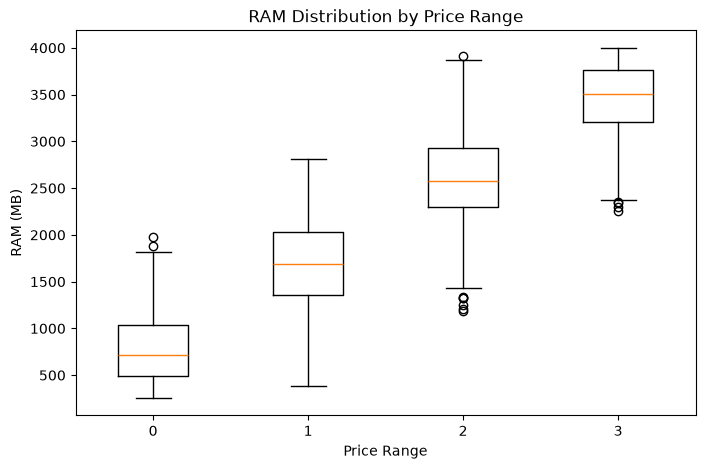

In [30]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    ram_groups,
    tick_labels=["0", "1", "2", "3"]
)

plt.title("RAM Distribution by Price Range")
plt.xlabel("Price Range")
plt.ylabel("RAM (MB)")

plt.show()

The boxplot shows a clear upward shift in RAM as the price category increases. Median RAM rises consistently from price range 0 to price range 3, with relatively limited overlap between the central portions of the distributions.

This visual pattern supports the previous statistical findings from the Spearman correlation, ANOVA and Kruskal-Wallis tests, all of which indicated a strong association between RAM and price classification.

Some observations appear as boxplot outliers, but they were retained because they remain plausible RAM values and are not necessarily data errors.

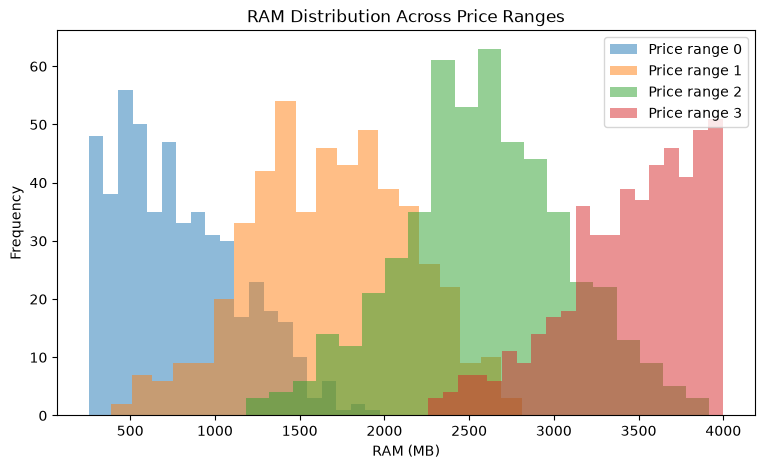

In [31]:
plt.figure(figsize=(9, 5))

for price in sorted(df["price_range"].unique()):
    plt.hist(
        df.loc[df["price_range"] == price, "ram"],
        bins=20,
        alpha=0.5,
        label=f"Price range {price}"
    )

plt.title("RAM Distribution Across Price Ranges")
plt.xlabel("RAM (MB)")
plt.ylabel("Frequency")
plt.legend()

plt.show()

The histogram shows a clear progressive shift toward higher RAM values as the price category increases.

Lower price ranges are concentrated at lower RAM levels, while higher price ranges are concentrated at higher RAM levels. Some overlap remains between adjacent categories, indicating that RAM is highly informative but does not completely separate the price classes by itself.

This pattern is consistent with the strong positive Spearman correlation previously observed between RAM and price range.

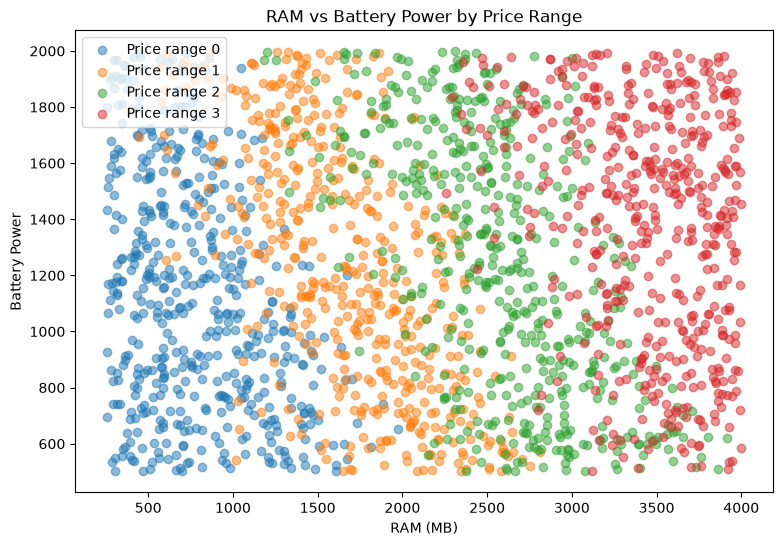

In [32]:
plt.figure(figsize=(9, 6))

for price in sorted(df["price_range"].unique()):
    subset = df[df["price_range"] == price]

    plt.scatter(
        subset["ram"],
        subset["battery_power"],
        alpha=0.5,
        label=f"Price range {price}"
    )

plt.title("RAM vs Battery Power by Price Range")
plt.xlabel("RAM (MB)")
plt.ylabel("Battery Power")
plt.legend()

plt.show()

The scatter plot shows that price categories are primarily separated along the RAM axis. Lower price ranges are concentrated at lower RAM values, while higher price ranges progressively shift toward higher RAM values.

Battery power varies considerably within every price category, producing substantial vertical overlap between the groups. This suggests that battery power provides some information about price classification, but its relationship is much weaker than that of RAM.

This visual pattern is consistent with the Spearman correlations, where RAM showed a very strong association with price range while battery power showed only a weak positive association.

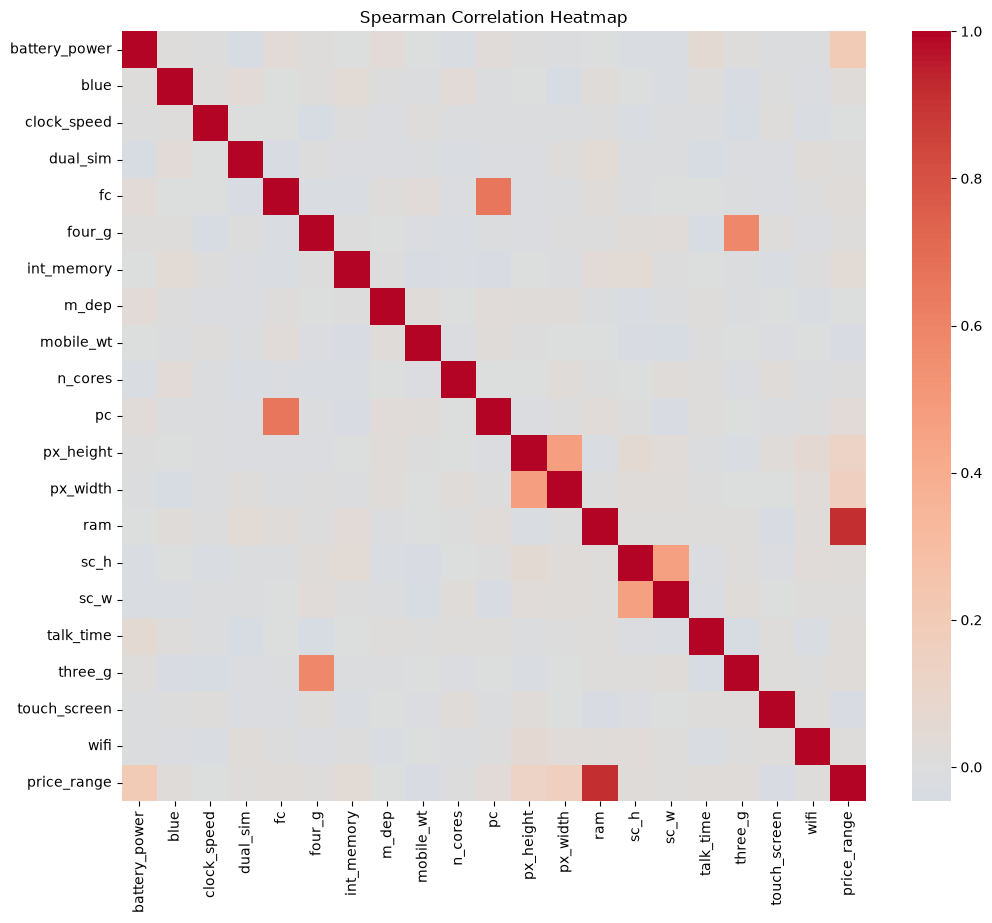

In [35]:
corr_matrix = df.corr(method="spearman")

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Spearman Correlation Heatmap")

plt.show()

### Correlation Heatmap

The Spearman correlation heatmap confirms that RAM has by far the strongest positive association with `price_range`.

Battery power, pixel width and pixel height show weaker positive associations with the target, while most other features have correlations close to zero.

Some relationships are also visible between related predictors, particularly front and primary camera resolution (`fc` and `pc`), pixel dimensions (`px_height` and `px_width`), screen dimensions (`sc_h` and `sc_w`), and network capabilities (`three_g` and `four_g`).

Overall, most predictors are only weakly correlated with one another, suggesting limited redundancy among the features.

# 5. Insight Synthesis and Conclusion

### Key Findings

- **RAM** is the dominant feature associated with mobile price range (`r ≈ 0.917`).
- **Battery power**, **pixel width**, and **pixel height** show weaker positive relationships with price classification.
- Both **ANOVA** and **Kruskal-Wallis** confirm significant differences in RAM across price categories.
- Most other features show weak or non-significant individual associations with price range.
- Statistical significance does not necessarily imply practical importance, as demonstrated by internal memory.
- Visual analysis strongly supports the statistical results.

## Synthesis and Conclusion

The analysis identified clear differences in how mobile phone features relate to price classification.

RAM emerged as by far the strongest feature associated with `price_range`. Its Spearman correlation with the target was approximately **0.917**, indicating a very strong positive monotonic relationship. Average RAM also increased consistently across the four price categories, from approximately **785 MB** in price range 0 to approximately **3,449 MB** in price range 3.

This relationship was confirmed through hypothesis testing. A one-way ANOVA produced an F-statistic of approximately **3520.11** with a p-value extremely close to zero, showing significant differences in mean RAM across price groups. The non-parametric Kruskal-Wallis test led to the same conclusion, with an H-statistic of approximately **1681.50** and a p-value close to zero.

Other features showed considerably weaker relationships with price classification. Battery power had a positive Spearman correlation of approximately **0.200**, followed by pixel width (**0.165**) and pixel height (**0.133**). These variables appear to provide some information about price category, but their individual relationships are much weaker than that of RAM.

An interesting result was that many features that could intuitively be expected to influence mobile pricing showed little or no monotonic association with the target. Features such as connectivity options, touch screen availability, number of processor cores, camera characteristics and talk time generally showed correlations close to zero.

Internal memory provided another useful statistical insight. Although its correlation with price range was statistically significant (`r ≈ 0.044`, `p ≈ 0.048`), the magnitude of the relationship was extremely small. This illustrates the distinction between statistical significance and practical importance.

The visualizations supported the statistical findings. RAM distributions progressively shifted toward higher values across increasing price ranges, while the RAM boxplots showed clearly increasing medians. The RAM versus battery power scatter plot also demonstrated that price classes were separated mainly along the RAM dimension rather than battery power.

The correlation heatmap additionally revealed expected relationships between related technical features, such as front and primary camera resolution, pixel dimensions, screen dimensions, and network capabilities, while most predictors showed relatively low correlations with each other.

Overall, the analysis suggests that **RAM is the most informative individual feature associated with mobile price classification in this dataset**, while battery power and screen resolution provide weaker additional signals. However, these results describe statistical associations and should not be interpreted as evidence that any individual feature directly causes a higher mobile price.